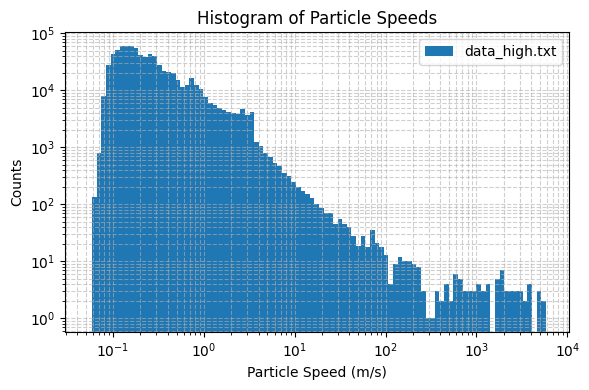

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# --- Load data ---
# Assuming the txt file has columns:
# ID, x, y, z, vx, vy, vz, mass, density
data = np.genfromtxt("/nuke/linfel/Ejecta/data_high.txt", delimiter=" ")

# Extract velocities (cm/s → m/s)
vx = data[:, 4] / 100.0
vy = data[:, 5] / 100.0
vz = data[:, 6] / 100.0

# Compute speed
speed_dust = np.sqrt(vx**2 + vy**2 + vz**2)

# --- Histogram bins ---
bins = np.logspace(np.log10(speed_dust.min()), np.log10(speed_dust.max()), num=100)

# --- Plot histogram ---
plt.figure(figsize=(6, 4))
counts, bin_edges = np.histogram(speed_dust, bins=bins)
plt.bar(bin_edges[:-1], counts, 
        width=bin_edges[1:] - bin_edges[:-1], 
        align='edge', 
        #edgecolor='black',
        label='data_high.txt'
       )

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Particle Speed (m/s)")
plt.ylabel("Counts")
plt.title("Histogram of Particle Speeds")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()


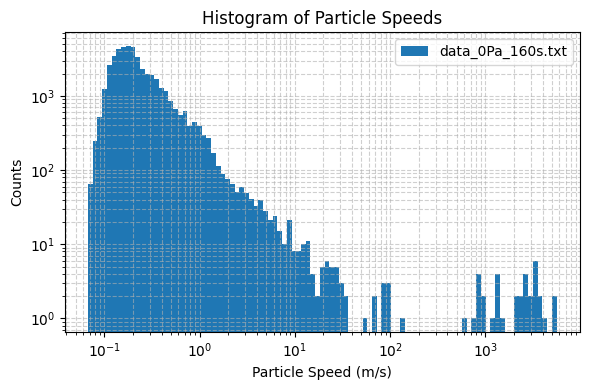

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# --- Load data ---
# Assuming the txt file has columns:
# ID, x, y, z, vx, vy, vz, mass, density
data = np.genfromtxt("/nuke/linfel/Ejecta/data_0Pa_160s_dimor_removed.txt", delimiter=" ")

# Extract velocities (cm/s → m/s)
vx = data[:, 4] / 100.0
vy = data[:, 5] / 100.0
vz = data[:, 6] / 100.0

# Compute speed
speed_dust = np.sqrt(vx**2 + vy**2 + vz**2)

# --- Histogram bins ---
bins = np.logspace(np.log10(speed_dust.min()), np.log10(speed_dust.max()), num=100)

# --- Plot histogram ---
plt.figure(figsize=(6, 4))
counts, bin_edges = np.histogram(speed_dust, bins=bins)
plt.bar(bin_edges[:-1], counts, 
        width=bin_edges[1:] - bin_edges[:-1], 
        align='edge', 
        #edgecolor='black',
        label='data_0Pa_160s.txt'
       )

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Particle Speed (m/s)")
plt.ylabel("Counts")
plt.title("Histogram of Particle Speeds")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()


In [9]:
"""
Remove constituent particles of Dimorphos from the raw data 'data_0Pa_160s.txt'
"""

import numpy as np

# Input and output file paths
input_file = "/nuke/linfel/Ejecta/data_0Pa_160s.txt"
output_file = "/nuke/linfel/Ejecta/data_0Pa_160s_dimor_removed.txt"

# Define radius of Dimorphos
Rsq_long_dimor = (193.0 / 2)**2

with open(input_file, "r") as fin, open(output_file, "w") as fout:
    for line in fin:
        # Skip empty lines
        if not line.strip():
            continue

        # Parse columns (convert to float)
        cols = line.split()
        x = float(cols[1]) / 100.0  # cm → m
        y = float(cols[2]) / 100.0
        z = float(cols[3]) / 100.0

        # Compute r^2
        r_square = x**2 + y**2 + z**2

        # Write the line if condition is met
        if r_square > Rsq_long_dimor:
            fout.write(line)

print(f"Filtering complete. Output saved to {output_file}")


Filtering complete. Output saved to /nuke/linfel/Ejecta/data_0Pa_160s_dimor_removed.txt
